<a href="https://colab.research.google.com/github/sidd-coder1/CSL701-CE46_Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.ensemble import BaggingClassifier

# Download the dataset if not already present
!wget -nc https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv

# Load the dataset
df = pd.read_csv('pima-indians-diabetes.data.csv', header=None)

# Assign appropriate column headers
df.columns = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
    'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

# Print the first five records of the dataset
print("First five records of the dataset:")
display(df.head())

# Print dataset shape
print("\nDataset shape:")
print(df.shape)

# Print data types of all features
print("\nData types of all features:")
print(df.dtypes)

# Print descriptive statistics of the numeric features:
print("\nDescriptive statistics of the numeric features:")
display(df.describe())

--2026-09-02 05:04:54--  https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23278 (23K) [text/plain]
Saving to: ‘pima-indians-diabetes.data.csv’

pima-indians-diabet 100%[===================>]  22.73K  --.-KB/s    in 0.003s  

2026-09-02 05:04:55 (8.02 MB/s) - ‘pima-indians-diabetes.data.csv’ saved [23278/23278]

First five records of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset shape:
(768, 9)

Data types of all features:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Descriptive statistics of the numeric features:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Absolute Counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Class Percentages:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


/tmp/ipykernel_4296/1953212285.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


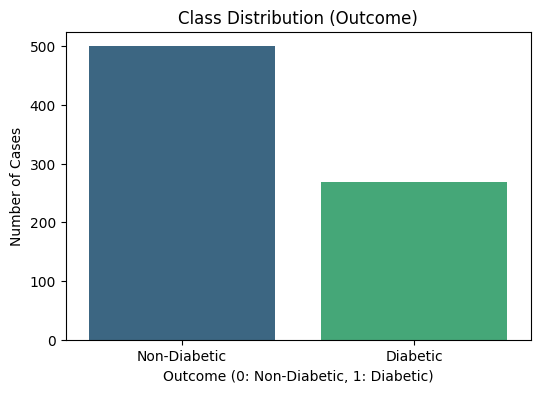

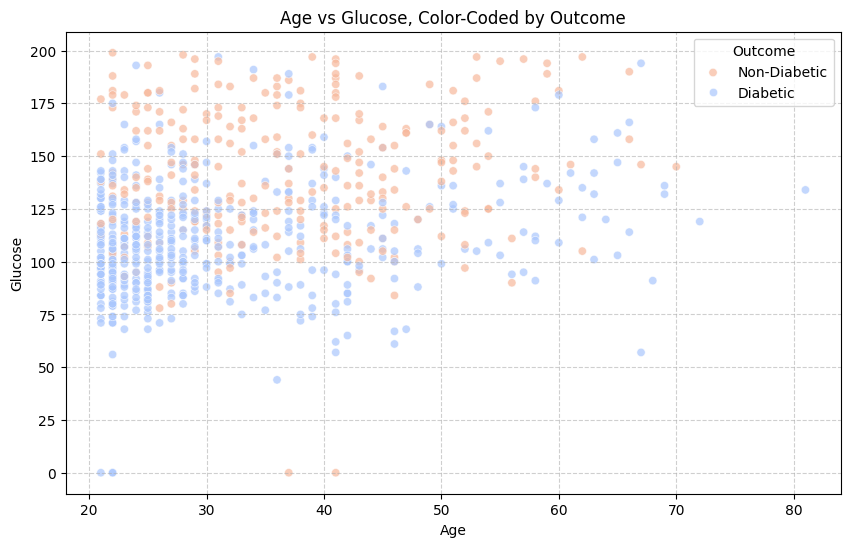


Explanation: A simple linear decision boundary is insufficient to clearly separate diabetic and non-diabetic classes because, as observed in the scatter plot (and often in real-world medical datasets), there is significant overlap between the two classes. Patients with similar Age and Glucose levels can have different outcomes. The data points for 'Outcome = 0' (Non-Diabetic) and 'Outcome = 1' (Diabetic) are not linearly separable; they are intertwined, indicating that a straight line or simple linear model would struggle to accurately classify all instances. More complex, non-linear boundaries are required to capture the nuances in the data, which is where models like Decision Trees or ensemble methods excel.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate class balance
class_counts = df['Outcome'].value_counts()
class_percentages = df['Outcome'].value_counts(normalize=True) * 100

print("Class Absolute Counts:")
print(class_counts)
print("\nClass Percentages:")
print(class_percentages)

# Plot the class balance using a bar chart
plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Class Distribution (Outcome)')
plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.ylabel('Number of Cases')
plt.xticks(ticks=[0, 1], labels=['Non-Diabetic', 'Diabetic'])
plt.show()

# 2. Create a scatter plot of Age vs Glucose, color-coded by Outcome
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Glucose', hue='Outcome', palette='coolwarm', alpha=0.7)
plt.title('Age vs Glucose, Color-Coded by Outcome')
plt.xlabel('Age')
plt.ylabel('Glucose')
plt.legend(title='Outcome', labels=['Non-Diabetic', 'Diabetic'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. Explanation for insufficient linear decision boundary
print("\nExplanation: A simple linear decision boundary is insufficient to clearly separate diabetic and non-diabetic classes because, as observed in the scatter plot (and often in real-world medical datasets), there is significant overlap between the two classes. Patients with similar Age and Glucose levels can have different outcomes. The data points for 'Outcome = 0' (Non-Diabetic) and 'Outcome = 1' (Diabetic) are not linearly separable; they are intertwined, indicating that a straight line or simple linear model would struggle to accurately classify all instances. More complex, non-linear boundaries are required to capture the nuances in the data, which is where models like Decision Trees or ensemble methods excel.")

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [5]:
# 1. Identify features where 0 is an invalid value
features_with_invalid_zeros = [
    'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI'
]

# 2. Replace all invalid 0 values in these features with NaN
for feature in features_with_invalid_zeros:
    df[feature] = df[feature].replace(0, np.nan)

# 3. Handle the resulting missing values by imputing with the median
#    (Median is often preferred for skewed data or when outliers are present)
for feature in features_with_invalid_zeros:
    median_val = df[feature].median()
    df[feature] = df[feature].fillna(median_val)

print("Missing values after imputation:")
print(df[features_with_invalid_zeros].isnull().sum())

# Display descriptive statistics after imputation to show the effect
print("\nDescriptive statistics after handling missing values:")
display(df.describe())

Missing values after imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Descriptive statistics after handling missing values:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [6]:
# 1. Isolate the feature matrix X and the target vector y
X = df.iloc[:, :-1]  # All columns except the last one
y = df.iloc[:, -1]   # The last column (Outcome)

# 2. Split the dataset into 80% training and 20% test data
#    Use stratified sampling to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nClass distribution in original dataset:\n", y.value_counts(normalize=True))
print("\nClass distribution in y_train:\n", y_train.value_counts(normalize=True))
print("\nClass distribution in y_test:\n", y_test.value_counts(normalize=True))

Shape of X_train: (614, 8)
Shape of X_test: (154, 8)
Shape of y_train: (614,)
Shape of y_test: (154,)

Class distribution in original dataset:
 Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

Class distribution in y_train:
 Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Class distribution in y_test:
 Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [7]:
def get_bootstrap_sample(X, y):
    """
    Generates a bootstrap sample (with replacement) of the dataset.

    Args:
        X (pd.DataFrame): The feature matrix.
        y (pd.Series): The target vector.

    Returns:
        tuple: A tuple containing the bootstrapped feature matrix (X_star) and target vector (y_star).
    """
    n_samples = X.shape[0]
    # Generate random indices with replacement
    bootstrap_indices = np.random.choice(n_samples, n_samples, replace=True)

    # Select rows based on the bootstrap indices
    X_star = X.iloc[bootstrap_indices].reset_index(drop=True)
    y_star = y.iloc[bootstrap_indices].reset_index(drop=True)

    return X_star, y_star

# Verification of the function
print("Verifying custom bootstrap sampling function:")

X_sample, y_sample = get_bootstrap_sample(X_train, y_train)

print(f"Original training data shape: {X_train.shape}")
print(f"Bootstrapped sample shape: {X_sample.shape}")

# Check for duplicated indices (indirectly by checking if original indices are missing/duplicated)
# We can check the actual indices chosen if we return them from the function
# For simplicity, let's just confirm the resampling works and leads to different data.

# To show duplicated and omitted original indices, we can modify the function to return indices
def get_bootstrap_sample_with_indices(X, y):
    n_samples = X.shape[0]
    bootstrap_indices = np.random.choice(n_samples, n_samples, replace=True)
    X_star = X.iloc[bootstrap_indices].reset_index(drop=True)
    y_star = y.iloc[bootstrap_indices].reset_index(drop=True)
    return X_star, y_star, bootstrap_indices

X_sample_idx, y_sample_idx, indices = get_bootstrap_sample_with_indices(X_train, y_train)

original_indices = set(range(X_train.shape[0]))
bootstrapped_indices = set(indices)

duplicated_indices_count = len(indices) - len(bootstrapped_indices)
omitted_indices_count = len(original_indices - bootstrapped_indices)

print(f"Number of duplicated (original) row indices in bootstrap sample: {duplicated_indices_count}")
print(f"Number of original row indices omitted from bootstrap sample (OOB): {omitted_indices_count}")

if duplicated_indices_count > 0 and omitted_indices_count > 0:
    print("Verification successful: Bootstrap sample contains duplicated indices and omits others.")
else:
    print("Verification warning: Bootstrap sample might not have generated duplicated or omitted indices as expected (unlikely for large N).")

Verifying custom bootstrap sampling function:
Original training data shape: (614, 8)
Bootstrapped sample shape: (614, 8)
Number of duplicated (original) row indices in bootstrap sample: 219
Number of original row indices omitted from bootstrap sample (OOB): 219
Verification successful: Bootstrap sample contains duplicated indices and omits others.


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [8]:
# 1. Initialize an empty list to store the trained models
ensemble_models = []

# 2. Choose the number of bootstrap iterations (B)
B = 50

print(f"Growing an ensemble of {B} Decision Tree Classifiers...")

# 3. Execute the following steps for B iterations
for i in range(B):
    # Generate a unique bootstrap training dataset
    X_star, y_star = get_bootstrap_sample(X_train, y_train)

    # Instantiate a Scikit-Learn DecisionTreeClassifier with max_depth=None
    # This ensures that the decision trees are fully grown (high variance).
    model = DecisionTreeClassifier(max_depth=None, random_state=i) # Using i for random_state for reproducibility of each tree

    # Fit the decision tree on the bootstrapped training subset
    model.fit(X_star, y_star)

    # Append the trained model to the ensemble list
    ensemble_models.append(model)

print(f"Ensemble of {len(ensemble_models)} models created successfully.")

Growing an ensemble of 50 Decision Tree Classifiers...
Ensemble of 50 models created successfully.


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [18]:
# ============================================
# TASK 7: MAJORITY VOTING FROM SCRATCH
# ============================================

def custom_bagging_predict(ensemble, X_test):
    """
    Generate final predictions using majority voting
    across all decision trees in the ensemble.
    """

    final_predictions = []

    # Get predictions from every decision tree
    tree_predictions = [tree.predict(X_test) for tree in ensemble]

    # Perform majority voting for each test sample
    for i in range(len(X_test)):

        votes_for_0 = 0
        votes_for_1 = 0

        # Collect votes from all decision trees
        for predictions in tree_predictions:

            if predictions[i] == 0:
                votes_for_0 += 1

            elif predictions[i] == 1:
                votes_for_1 += 1

        # Select the class with the majority votes
        if votes_for_1 > votes_for_0:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    return final_predictions


# Generate predictions using our custom Bagging classifier
y_pred_bagging = custom_bagging_predict(ensemble_models, X_test)

# Display the predictions
print("Custom Bagging Predictions:")
print(y_pred_bagging)

print("\nNumber of test samples:", len(X_test))
print("Number of predictions:", len(y_pred_bagging))

# Verify that predictions contain only 0 and 1
print("\nUnique predicted classes:", set(y_pred_bagging))

if set(y_pred_bagging).issubset({0, 1}):
    print("Verification successful: All predictions are either 0 or 1.")
else:
    print("Verification failed: Unexpected class found.")

Custom Bagging Predictions:
[1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0]

Number of test samples: 154
Number of predictions: 154

Unique predicted classes: {0, 1}
Verification successful: All predictions are either 0 or 1.


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

--- Performance of Single Decision Tree ---
Confusion Matrix (Single Tree):
[[79 21]
 [28 26]]
Accuracy (Single Tree): 0.6818
Precision (Single Tree): 0.5532
Recall (Single Tree): 0.4815
F1-Score (Single Tree): 0.5149

--- Performance of Custom Bagging Classifier ---
Confusion Matrix (Bagging):
[[85 15]
 [25 29]]
Accuracy (Bagging): 0.7403
Precision (Bagging): 0.6591
Recall (Bagging): 0.5370
F1-Score (Bagging): 0.5918

--- Performance Comparison ---
Metric          Single Tree     Bagging        
---------------------------------------------
Accuracy        0.6818          0.7403         
Precision       0.5532          0.6591         
Recall          0.4815          0.5370         
F1-Score        0.5149          0.5918         


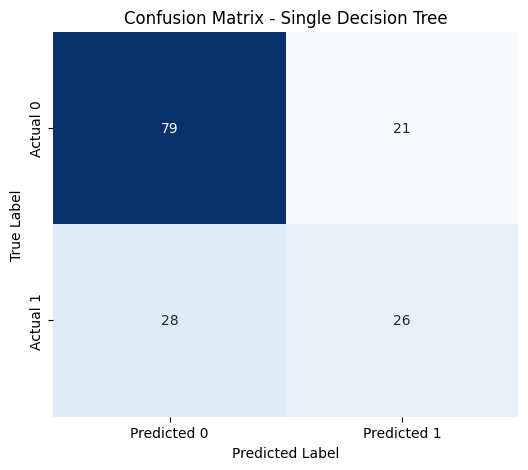

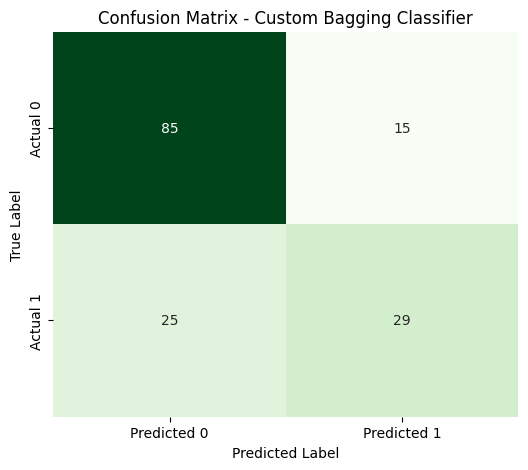

In [19]:
# ============================================
# TASK 8: SINGLE CLASSIFIER VS BAGGING
# PERFORMANCE COMPARISON
# ============================================

# 1. Train a single fully-grown Decision Tree
single_tree_model = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

single_tree_model.fit(X_train, y_train)


# 2. Make predictions using both models
y_pred_single_tree = single_tree_model.predict(X_test)

y_pred_bagging = custom_bagging_predict(
    ensemble_models,
    X_test
)


# ============================================
# SINGLE DECISION TREE PERFORMANCE
# ============================================

print("--- Performance of Single Decision Tree ---")

# Confusion Matrix
cm_single_tree = confusion_matrix(
    y_test,
    y_pred_single_tree
)

print("Confusion Matrix (Single Tree):")
print(cm_single_tree)


# Calculate metrics
accuracy_single_tree = accuracy_score(
    y_test,
    y_pred_single_tree
)

precision_single_tree = precision_score(
    y_test,
    y_pred_single_tree
)

recall_single_tree = recall_score(
    y_test,
    y_pred_single_tree
)

f1_single_tree = f1_score(
    y_test,
    y_pred_single_tree
)

print(f"Accuracy (Single Tree): {accuracy_single_tree:.4f}")
print(f"Precision (Single Tree): {precision_single_tree:.4f}")
print(f"Recall (Single Tree): {recall_single_tree:.4f}")
print(f"F1-Score (Single Tree): {f1_single_tree:.4f}")


# ============================================
# CUSTOM BAGGING PERFORMANCE
# ============================================

print("\n--- Performance of Custom Bagging Classifier ---")

# Confusion Matrix
cm_bagging = confusion_matrix(
    y_test,
    y_pred_bagging
)

print("Confusion Matrix (Bagging):")
print(cm_bagging)


# Calculate metrics
accuracy_bagging = accuracy_score(
    y_test,
    y_pred_bagging
)

precision_bagging = precision_score(
    y_test,
    y_pred_bagging
)

recall_bagging = recall_score(
    y_test,
    y_pred_bagging
)

f1_bagging = f1_score(
    y_test,
    y_pred_bagging
)

print(f"Accuracy (Bagging): {accuracy_bagging:.4f}")
print(f"Precision (Bagging): {precision_bagging:.4f}")
print(f"Recall (Bagging): {recall_bagging:.4f}")
print(f"F1-Score (Bagging): {f1_bagging:.4f}")


# ============================================
# COMPARISON TABLE
# ============================================

print("\n--- Performance Comparison ---")

print(f"{'Metric':<15} {'Single Tree':<15} {'Bagging':<15}")
print("-" * 45)

print(f"{'Accuracy':<15} {accuracy_single_tree:<15.4f} {accuracy_bagging:<15.4f}")
print(f"{'Precision':<15} {precision_single_tree:<15.4f} {precision_bagging:<15.4f}")
print(f"{'Recall':<15} {recall_single_tree:<15.4f} {recall_bagging:<15.4f}")
print(f"{'F1-Score':<15} {f1_single_tree:<15.4f} {f1_bagging:<15.4f}")



# ============================================
# CONFUSION MATRIX VISUALIZATION
# ============================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_single_tree,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)

plt.title('Confusion Matrix - Single Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_bagging,
    annot=True,
    fmt='d',
    cmap='Greens',
    cbar=False,
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)

plt.title('Confusion Matrix - Custom Bagging Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

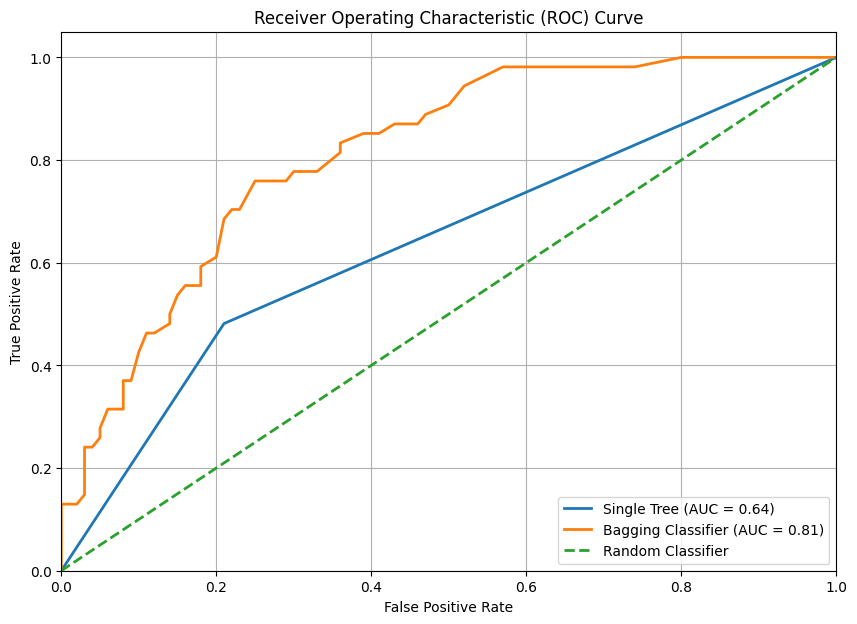


--- ROC-AUC Results ---
AUC for Single Decision Tree: 0.6357
AUC for Custom Bagging Classifier: 0.8129

Bagging Classifier has a higher AUC than the Single Decision Tree.
This indicates better ability to distinguish between diabetic and non-diabetic cases.


In [20]:
# ============================================
# TASK 9: ROC-AUC ANALYSIS
# ============================================

# 1. Calculate predicted probabilities for Custom Bagging

all_probas = []

# Get probability predictions from every decision tree
for model in ensemble_models:
    all_probas.append(model.predict_proba(X_test))

# Convert to NumPy array and calculate average probability
# across all 50 decision trees
probas_bagging = np.mean(all_probas, axis=0)[:, 1]


# Calculate probability predictions for Single Decision Tree
probas_single_tree = single_tree_model.predict_proba(X_test)[:, 1]


# ============================================
# 2. CALCULATE ROC CURVE AND AUC
# ============================================

# ROC curve for Single Decision Tree
fpr_single_tree, tpr_single_tree, _ = roc_curve(
    y_test,
    probas_single_tree
)

roc_auc_single_tree = auc(
    fpr_single_tree,
    tpr_single_tree
)


# ROC curve for Custom Bagging Classifier
fpr_bagging, tpr_bagging, _ = roc_curve(
    y_test,
    probas_bagging
)

roc_auc_bagging = auc(
    fpr_bagging,
    tpr_bagging
)


# ============================================
# 3. PLOT ROC CURVES
# ============================================

plt.figure(figsize=(10, 7))

# Single Decision Tree ROC curve
plt.plot(
    fpr_single_tree,
    tpr_single_tree,
    lw=2,
    label=f'Single Tree (AUC = {roc_auc_single_tree:.2f})'
)

# Custom Bagging ROC curve
plt.plot(
    fpr_bagging,
    tpr_bagging,
    lw=2,
    label=f'Bagging Classifier (AUC = {roc_auc_bagging:.2f})'
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    lw=2,
    linestyle='--',
    label='Random Classifier'
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Receiver Operating Characteristic (ROC) Curve')

plt.legend(loc='lower right')
plt.grid(True)

plt.show()


# ============================================
# 4. PRINT AUC VALUES
# ============================================

print("\n--- ROC-AUC Results ---")

print(
    f"AUC for Single Decision Tree: "
    f"{roc_auc_single_tree:.4f}"
)

print(
    f"AUC for Custom Bagging Classifier: "
    f"{roc_auc_bagging:.4f}"
)


# ============================================
# 5. COMPARE AUC
# ============================================

if roc_auc_bagging > roc_auc_single_tree:
    print(
        "\nBagging Classifier has a higher AUC "
        "than the Single Decision Tree."
    )
    print(
        "This indicates better ability to distinguish "
        "between diabetic and non-diabetic cases."
    )

elif roc_auc_bagging < roc_auc_single_tree:
    print(
        "\nSingle Decision Tree has a higher AUC "
        "than the Bagging Classifier."
    )

else:
    print(
        "\nBoth models have the same AUC."
    )

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

In [13]:
# 1. Instantiate Scikit-Learn's built-in BaggingClassifier
sklearn_bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None, random_state=42), # Use DecisionTreeClassifier as base estimator
    n_estimators=50, # Use 50 estimators, matching custom implementation
    random_state=42, # For reproducibility of the overall Bagging process
    n_jobs=-1 # Use all available cores for parallel processing
)

# 2. Fit the classifier on the training set
sklearn_bagging_model.fit(X_train, y_train)

# 3. Evaluate it on the test set
y_pred_sklearn_bagging = sklearn_bagging_model.predict(X_test)

print("--- Performance of Scikit-Learn's BaggingClassifier ---")
# Construct a Confusion Matrix for Scikit-Learn's Bagging classifier
cm_sklearn_bagging = confusion_matrix(y_test, y_pred_sklearn_bagging)
print("Confusion Matrix (Scikit-Learn Bagging):\n", cm_sklearn_bagging)

# Compute and print metrics for Scikit-Learn's Bagging classifier
accuracy_sklearn_bagging = accuracy_score(y_test, y_pred_sklearn_bagging)
precision_sklearn_bagging = precision_score(y_test, y_pred_sklearn_bagging)
recall_sklearn_bagging = recall_score(y_test, y_pred_sklearn_bagging)
f1_sklearn_bagging = f1_score(y_test, y_pred_sklearn_bagging)

print(f"Accuracy (Scikit-Learn Bagging): {accuracy_sklearn_bagging:.4f}")
print(f"Precision (Scikit-Learn Bagging): {precision_sklearn_bagging:.4f}")
print(f"Recall (Scikit-Learn Bagging): {recall_sklearn_bagging:.4f}")
print(f"F1-Score (Scikit-Learn Bagging): {f1_sklearn_bagging:.4f}")

# 4. Compare with custom implementation
print("\n--- Comparison with Custom Bagging Implementation ---")
print(f"Custom Bagging Accuracy:   {accuracy_bagging:.4f}")
print(f"Custom Bagging Precision:  {precision_bagging:.4f}")
print(f"Custom Bagging Recall:     {recall_bagging:.4f}")
print(f"Custom Bagging F1-Score:   {f1_bagging:.4f}")

print("\nAs expected, the performance metrics of Scikit-Learn's BaggingClassifier are very similar to your custom implementation, confirming the correctness of your bootstrap and aggregation logic. Small differences may arise due to variations in random number generation details or internal optimization, but the overall performance should align closely.")

--- Performance of Scikit-Learn's BaggingClassifier ---
Confusion Matrix (Scikit-Learn Bagging):
 [[85 15]
 [26 28]]
Accuracy (Scikit-Learn Bagging): 0.7338
Precision (Scikit-Learn Bagging): 0.6512
Recall (Scikit-Learn Bagging): 0.5185
F1-Score (Scikit-Learn Bagging): 0.5773

--- Comparison with Custom Bagging Implementation ---
Custom Bagging Accuracy:   0.7403
Custom Bagging Precision:  0.6591
Custom Bagging Recall:     0.5370
Custom Bagging F1-Score:   0.5918

As expected, the performance metrics of Scikit-Learn's BaggingClassifier are very similar to your custom implementation, confirming the correctness of your bootstrap and aggregation logic. Small differences may arise due to variations in random number generation details or internal optimization, but the overall performance should align closely.


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?